# P3 Diverse Run: Eval Summary

This notebook finds the latest `p3_diverse_*` run, locates the eval outputs, 
builds a results table, and plots bar charts for each benchmark.

If you want a specific run, set `RUN_ID` in the first code cell.


In [1]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path('.').resolve()
LOG_ROOT = ROOT / 'p3_logs' / 'config'
RESULT_ROOT = ROOT / 'p3_results' / 'config'

RUN_ID = None  # e.g., 'p3_diverse_20260107_233913_8763'

def find_latest_run(prefix='p3_diverse_'):
    if not LOG_ROOT.exists():
        raise FileNotFoundError(f'Log root not found: {LOG_ROOT}')
    runs = [p for p in LOG_ROOT.glob(f'{prefix}*') if p.is_dir()]
    if not runs:
        raise FileNotFoundError(f'No runs found in {LOG_ROOT}')
    runs.sort(key=lambda p: p.stat().st_mtime)
    return runs[-1].name

if RUN_ID is None:
    RUN_ID = find_latest_run()

LOG_DIR = LOG_ROOT / RUN_ID
RESULT_DIR = RESULT_ROOT / RUN_ID

print('RUN_ID:', RUN_ID)
print('LOG_DIR:', LOG_DIR)
print('RESULT_DIR:', RESULT_DIR)


RUN_ID: p3_diverse_20260107_233913_8763
LOG_DIR: /home/heck2/sbhansali8/FTL/p3_logs/config/p3_diverse_20260107_233913_8763
RESULT_DIR: /home/heck2/sbhansali8/FTL/p3_results/config/p3_diverse_20260107_233913_8763


In [2]:
# Parse eval log output dirs (for reference / sanity check)
output_rows = []
output_re = re.compile(r'output dir is (.+)')

for log_path in sorted(LOG_DIR.glob('eval_*.log')):
    text = log_path.read_text(errors='ignore')
    m = output_re.search(text)
    run = bench = None
    match = re.match(r'eval_(.+?)_([a-z0-9]+)\.log', log_path.name)
    if match:
        run, bench = match.group(1), match.group(2)
    output_rows.append({
        'log': log_path.name,
        'run': run,
        'benchmark': bench,
        'output_dir': m.group(1) if m else None,
    })

output_df = pd.DataFrame(output_rows)
display(output_df)


,log,run,benchmark,output_dir
0,eval_bank_perclient_gsm8k.log,bank_perclient,gsm8k,/home/heck2/sbhansali8/FTL/p3_results/config/p...
1,eval_bank_perclient_humaneval.log,bank_perclient,humaneval,/home/heck2/sbhansali8/FTL/p3_results/config/p...
2,eval_bank_perclient_mmlu.log,bank_perclient,mmlu,/home/heck2/sbhansali8/FTL/p3_results/config/p...
3,eval_centralized_gsm8k.log,centralized,gsm8k,/home/heck2/sbhansali8/FTL/p3_results/config/p...
4,eval_centralized_humaneval.log,centralized,humaneval,/home/heck2/sbhansali8/FTL/p3_results/config/p...
5,eval_centralized_mmlu.log,centralized,mmlu,/home/heck2/sbhansali8/FTL/p3_results/config/p...
6,eval_fedavg_gsm8k.log,fedavg,gsm8k,/home/heck2/sbhansali8/FTL/p3_results/config/p...
7,eval_fedavg_humaneval.log,fedavg,humaneval,/home/heck2/sbhansali8/FTL/p3_results/config/p...
8,eval_fedavg_mmlu.log,fedavg,mmlu,/home/heck2/sbhansali8/FTL/p3_results/config/p...


In [3]:
runs = ['centralized', 'fedavg', 'bank_perclient']
benches = ['mmlu', 'gsm8k', 'humaneval']

def find_accuracy_file(run, bench):
    base = RESULT_DIR / 'global' / run / bench
    if not base.exists():
        return None
    candidates = sorted(base.glob('**/eval_result/accuracies__*.json'))
    if not candidates:
        return None
    if bench == 'mmlu':
        for path in candidates:
            name = path.name
            if '__gsm8k' in name or '__humaneval' in name:
                continue
            return path
        return None
    if bench == 'gsm8k':
        for path in candidates:
            if '__gsm8k' in path.name:
                return path
        return None
    if bench == 'humaneval':
        for path in candidates:
            if '__humaneval' in path.name:
                return path
        return None
    return None

def parse_metric(path, bench):
    data = json.loads(path.read_text())
    if bench == 'mmlu':
        return 'weighted_accuracy', data.get('weighted_accuracy')
    if bench == 'gsm8k':
        val = data.get('weighted_accuracy')
        if val is None:
            val = data.get('categories', {}).get('gsm8k')
        return 'weighted_accuracy', val
    if bench == 'humaneval':
        return 'pass@1', data.get('pass@1')
    return None, None

rows = []
missing = []
for run in runs:
    for bench in benches:
        path = find_accuracy_file(run, bench)
        if path is None:
            missing.append((run, bench))
            rows.append({
                'run': run,
                'benchmark': bench,
                'metric': None,
                'value': None,
                'result_path': None,
            })
            continue
        metric, value = parse_metric(path, bench)
        rows.append({
            'run': run,
            'benchmark': bench,
            'metric': metric,
            'value': value,
            'result_path': str(path),
        })

results_df = pd.DataFrame(rows)
display(results_df)

if missing:
    print('Missing results:')
    for item in missing:
        print('  -', item)


,run,benchmark,metric,value,result_path
0,centralized,mmlu,weighted_accuracy,0.500000,/home/heck2/sbhansali8/FTL/p3_results/config/p...
1,centralized,gsm8k,weighted_accuracy,0.128127,/home/heck2/sbhansali8/FTL/p3_results/config/p...
2,centralized,humaneval,pass@1,0.137805,/home/heck2/sbhansali8/FTL/p3_results/config/p...
3,fedavg,mmlu,weighted_accuracy,0.552632,/home/heck2/sbhansali8/FTL/p3_results/config/p...
4,fedavg,gsm8k,weighted_accuracy,0.088704,/home/heck2/sbhansali8/FTL/p3_results/config/p...
5,fedavg,humaneval,pass@1,0.103659,/home/heck2/sbhansali8/FTL/p3_results/config/p...
6,bank_perclient,mmlu,weighted_accuracy,0.543860,/home/heck2/sbhansali8/FTL/p3_results/config/p...
7,bank_perclient,gsm8k,weighted_accuracy,0.109932,/home/heck2/sbhansali8/FTL/p3_results/config/p...
8,bank_perclient,humaneval,pass@1,0.101220,/home/heck2/sbhansali8/FTL/p3_results/config/p...


In [4]:
# Wide summary table per run
wide = results_df.pivot(index='run', columns='benchmark', values='value')
display(wide)


benchmark,gsm8k,humaneval,mmlu
run,,,
bank_perclient,0.109932,0.101220,0.543860
centralized,0.128127,0.137805,0.500000
fedavg,0.088704,0.103659,0.552632


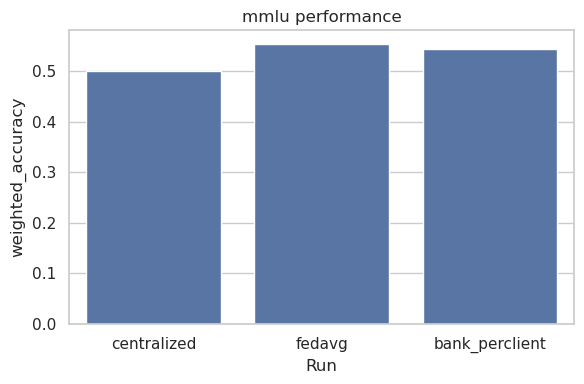

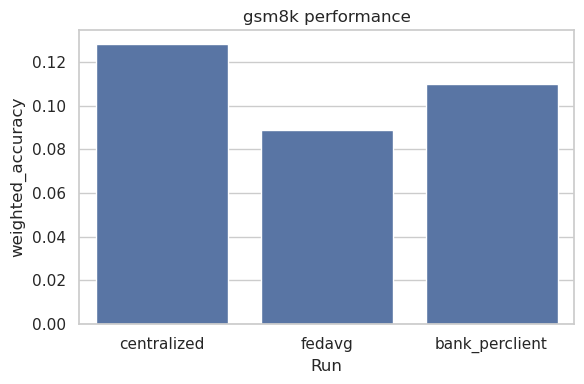

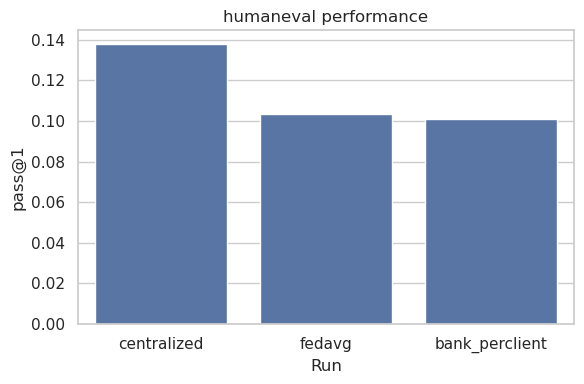

In [5]:
# Bar charts per benchmark
order = ['centralized', 'fedavg', 'bank_perclient']
for bench in benches:
    data = results_df[results_df['benchmark'] == bench].copy()
    plt.figure(figsize=(6, 4))
    sns.barplot(data=data, x='run', y='value', order=order)
    plt.title(f'{bench} performance')
    plt.xlabel('Run')
    plt.ylabel(data['metric'].dropna().iloc[0] if not data['metric'].dropna().empty else 'metric')
    plt.tight_layout()
    plt.show()
